<a href="https://colab.research.google.com/github/nishanthsnaik/SCT_ML_1/blob/main/ML_02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

In [5]:
dataset = pd.read_csv("/content/Mall_Customers (1).csv")

In [6]:
dataset.shape

(200, 5)

In [18]:
dataset.head(100)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4
...,...,...,...,...,...,...
95,96,Male,24,60,52,0
96,97,Female,47,60,47,0
97,98,Female,27,60,50,0
98,99,Male,48,61,42,0


In [8]:
X=dataset[['Annual Income (k$)','Spending Score (1-100)']]

In [9]:
SSD=[]

In [10]:
for i in range(1,11):
  kmeans = KMeans(n_clusters=i,random_state=42)
  kmeans.fit(X)
  SSD.append(kmeans.inertia_)

In [11]:
print(len(SSD))

10


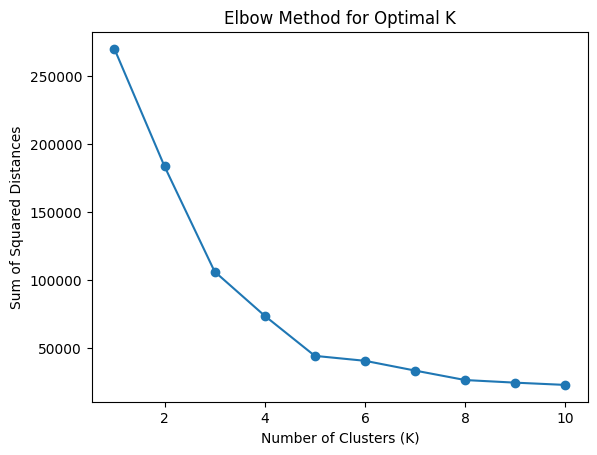

In [12]:
plt.plot(range(1, 11), SSD, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Distances')
plt.title('Elbow Method for Optimal K')
plt.show()

In [13]:
kmeans=KMeans(n_clusters=5,random_state=42)
clusters=kmeans.fit_predict(X)
dataset['Cluster']=clusters

In [15]:
centriods = kmeans.cluster_centers_
print(centriods)

[[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]


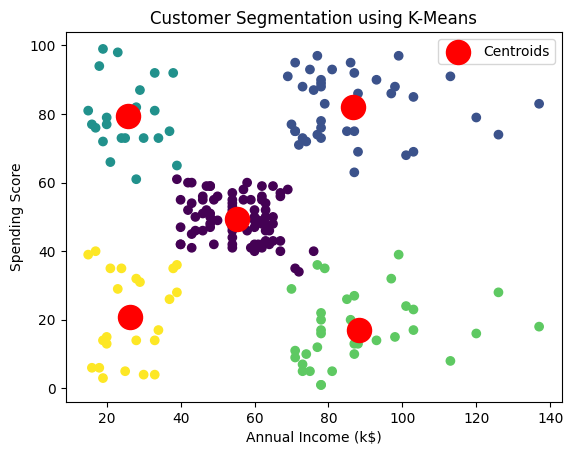

In [16]:
plt.scatter(X.iloc[:, 0], X.iloc[:, 1], c=clusters, cmap='viridis')
plt.scatter(centriods[:, 0], centriods[:, 1], s=300, c='red', label='Centroids')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score')
plt.title('Customer Segmentation using K-Means')
plt.legend()
plt.show()

In [17]:
print("Final SSE:", kmeans.inertia_)

Final SSE: 44448.45544793369


The K-Means model successfully grouped customers into 5 homogeneous clusters by minimizing within-cluster variance (SSE). The Elbow method indicates K=5 as optimal, providing meaningful segmentation for business decision-making